# Normalizing Flows in 2D

A normalizing flow composes invertible maps
$$
z_{k+1} = T_k(z_k),\qquad
\log p_X(x)=\log p_Z(z)-\sum_k \log|\det J_{T_k}(z_k)|.
$$
We build a didactic affine-coupling flow and visualize transformed samples.

A normalizing flow transports a simple density through invertible maps. If $x=T(z)$, then
$$\log p_X(x)=\log p_Z(z)-\log|\det DT(z)|.$$
The two-dimensional construction lets us inspect deformation, samples, and density correction together, emphasizing why invertibility and Jacobian determinants are central.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/normalizing-flows-2d/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/normalizing-flows-2d") if Path("python/normalizing-flows-2d").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Normalizing Flows in 2D**, with equations and plots designed to expose both the model and the numerical behavior.


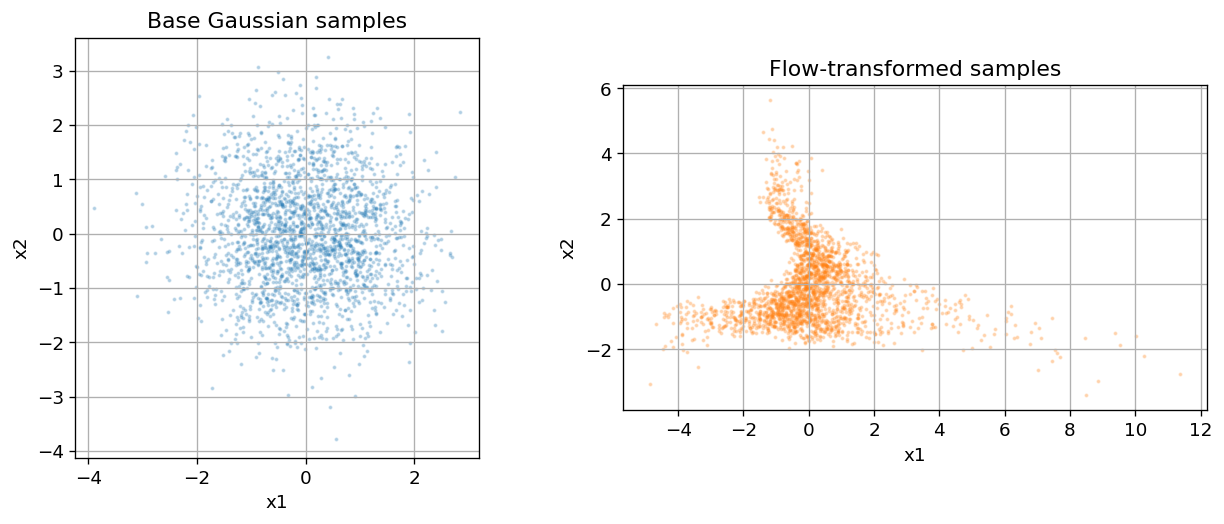

In [2]:
N = 2200
z = rng.normal(size=(N, 2))

def coupling(x, a=0.7, b=0.4):
    y = x.copy()
    y[:, 0] = x[:, 0]
    scale = np.exp(a * np.tanh(x[:, 0]))
    shift = b * np.sin(2.0 * x[:, 0])
    y[:, 1] = scale * x[:, 1] + shift
    logdet = np.log(scale)
    return y, logdet

def rotate(x, theta=0.55):
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s], [s, c]])
    return x @ R.T

x1, ld1 = coupling(z, a=0.9, b=0.55)
x2 = rotate(x1, theta=0.8)
x3, ld2 = coupling(x2[:, ::-1], a=-0.7, b=0.35)
x = x3[:, ::-1]

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.5))
axes[0].scatter(z[:, 0], z[:, 1], s=2, alpha=0.22)
axes[0].set_title("Base Gaussian samples")
axes[1].scatter(x[:, 0], x[:, 1], s=2, alpha=0.22, color="tab:orange")
axes[1].set_title("Flow-transformed samples")
for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- D. J. Rezende, S. Mohamed, "Variational Inference with Normalizing Flows", ICML, 2015.
- L. Dinh, J. Sohl-Dickstein, S. Bengio, "Density Estimation using Real NVP", ICLR, 2017.
- R. T. Q. Chen et al., "Neural Ordinary Differential Equations", NeurIPS, 2018.
